# 1.下载预训练模型权重文件和视频素材

In [1]:
import os

# 创建 checkpoint 文件夹，用于存放预训练模型权重文件
os.mkdir('checkpoint')

# 创建 outputs 文件夹，用于存放预测结果
os.mkdir('outputs')

# 创建 data 文件夹，用于存放图片和视频素材
os.mkdir('data')

# 创建 图表 文件夹，用于存放生成的图表
os.mkdir('图表')

# 创建 Zihao-Configs 文件夹，用于存放自己的语义分割模型的 config 配置文件
os.mkdir('Zihao-Configs')

# 2.检查安装成功

In [2]:
# 检查 Pytorch
import torch, torchvision
print('Pytorch 版本', torch.__version__)
print('CUDA 是否可用',torch.cuda.is_available())

Pytorch 版本 1.10.1+cu113
CUDA 是否可用 True


In [2]:
# 检查 mmcv
import mmcv
from mmcv.ops import get_compiling_cuda_version, get_compiler_version
print('MMCV版本', mmcv.__version__)
print('CUDA版本', get_compiling_cuda_version())
print('编译器版本', get_compiler_version())

MMCV版本 2.0.0
CUDA版本 11.3
编译器版本 GCC 9.3


In [3]:
# 检查 mmsegmentation
import mmseg
from mmseg.utils import register_all_modules
from mmseg.apis import inference_model, init_model
print('mmsegmentation版本', mmseg.__version__)

mmsegmentation版本 1.1.1


# 3.设置Matplotlib中文字体（具体问题具体分析）

--2026-04-01 17:42:39--  https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf
Resolving zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com (zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com)... 121.36.235.132
Connecting to zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com (zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com)|121.36.235.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10050868 (9.6M) [application/x-font-ttf]
Saving to: ‘/root/miniconda3/envs/mmseg_env/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf’

/root/miniconda3/en 100%[===================>]   9.58M  21.9MB/s    in 0.4s    

2026-04-01 17:42:40 (21.9 MB/s) - ‘/root/miniconda3/envs/mmseg_env/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf’ saved [10050868/10050868]

中文字体配置与缓存清理完成！


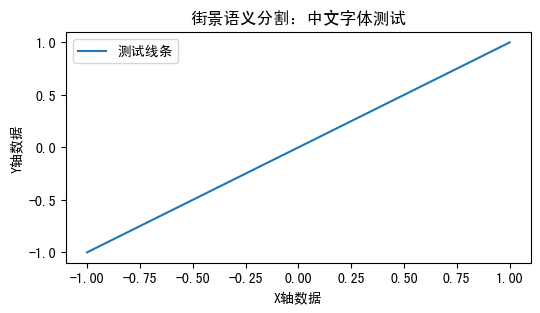

In [1]:
# Linux操作系统，例如 云GPU平台：https://featurize.cn 或者 https://www.autodl.com/home
# 1. 下载 SimHei 字体到 mmseg_env 虚拟环境的 matplotlib 字体库中
!wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf -O /root/miniconda3/envs/mmseg_env/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf

# 2. 删除 matplotlib 的旧字体缓存，强迫它去读取刚刚下载的新字体
!rm -rf /root/.cache/matplotlib

# 3. 导入绘图库并设置中文
import matplotlib
import matplotlib.pyplot as plt

# 设置中文字体为黑体 (SimHei)
matplotlib.rc("font", family='SimHei') 
# 解决设置中文字体后，坐标轴上的负号 ('-') 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

print("中文字体配置与缓存清理完成！")

# 4. 跑一个小测试，看看中文能不能正常显示
plt.figure(figsize=(6, 3))
plt.plot([-1, 0, 1], [-1, 0, 1], label='测试线条')
plt.title('街景语义分割：中文字体测试') 
plt.xlabel('X轴数据')
plt.ylabel('Y轴数据')
plt.legend()
plt.show()

In [ ]:
# # windows操作系统
# plt.rcParams['font.sans-serif']=['SimHei']  # 用来正常显示中文标签 
# plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号

In [ ]:
# Mac操作系统，参考 https://www.ngui.cc/51cto/show-727683.html
# 下载 simhei.ttf 字体文件
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf